# 34 — Trust-graph algebraic connectivity and the Zollman transient

**Why this notebook exists (Plan P5).** The paper relates its mechanism to Zollman's
speed/accuracy trade-off: *the algebraic connectivity of the trust graph governs the
transient* — denser graphs reorganize faster but spend the transient diversity that, near a
lock-in boundary, shields a community from committing to the worse paradigm. The connectivity
measure is the **Fiedler value** $\lambda_2$, the second-smallest eigenvalue of the graph
Laplacian $L=D-A$: zero iff the graph is disconnected, larger when it mixes faster
(`graphs.algebraic_connectivity`).

The paper also draws the **bubble vs echo chamber** distinction (Nguyen) as a statement about
channels: a *bubble* is a missing channel that exposure dissolves; an *echo chamber* is a
channel present but held at $\pi_s\approx 0$, which exposure only reinforces. Here the curator
sets the social channel — the trust graph's $\lambda_2$.

In [1]:
%matplotlib inline
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.structural.phlogiston import StructuralConfig
from src.structural import step as S, graphs as G, observables as obs

N = 60
print('lambda_2 across families (N=60, mean_degree=4 where applicable):')
for name, g in [('ring',          G.ring(N, mean_degree=2)),
                ('watts (p=0.1)', G.watts_strogatz(N, mean_degree=4, rewiring_p=0.1)),
                ('watts (p=1.0)', G.watts_strogatz(N, mean_degree=4, rewiring_p=1.0)),
                ('complete',      G.complete(N))]:
    print(f'  {name:14s} lambda_2 = {G.algebraic_connectivity(g):8.4f}')

lambda_2 across families (N=60, mean_degree=4 where applicable):
  ring           lambda_2 =   0.0110
  watts (p=0.1)  lambda_2 =   0.1345
  watts (p=1.0)  lambda_2 =   0.6549
  complete       lambda_2 =  60.0000


## §1 — The connectivity axis: Watts–Strogatz rewiring at fixed degree

Rewiring a ring lattice raises $\lambda_2$ while holding the **mean degree fixed** — so we can
vary connectivity without the degree confound. This is the clean knob for the sweeps below.

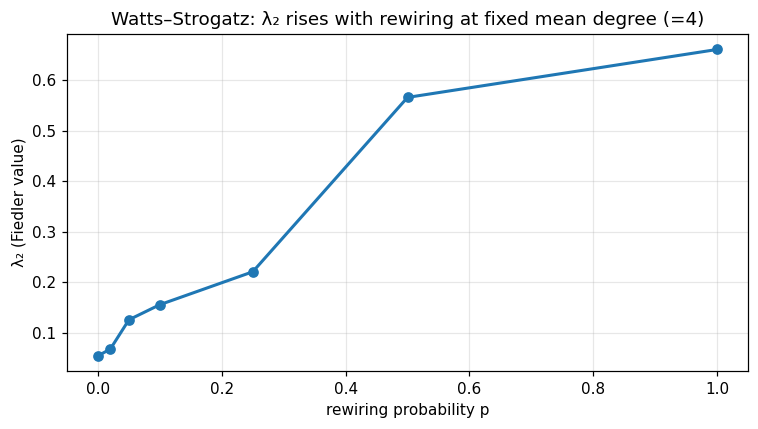

λ₂ by p: {0.0: 0.055, 0.02: 0.068, 0.05: 0.126, 0.1: 0.156, 0.25: 0.221, 0.5: 0.566, 1.0: 0.66}


In [2]:
ps = np.array([0.0, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0])
l2s = np.array([G.algebraic_connectivity(G.watts_strogatz(N, mean_degree=4, rewiring_p=p, seed=1)) for p in ps])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ps, l2s, 'o-', lw=2)
ax.set_xlabel('rewiring probability p'); ax.set_ylabel('λ₂ (Fiedler value)')
ax.set_title('Watts–Strogatz: λ₂ rises with rewiring at fixed mean degree (=4)')
plt.tight_layout(); plt.savefig('figures_nb34_axis.png'); plt.show()
print('λ₂ by p:', dict(zip(ps.tolist(), np.round(l2s, 3).tolist())))

## §2 — Bubble vs echo chamber: λ₂ governs whether the truth crosses

The decisive setup. Two communities: an **informed bubble** (an oxygen vanguard that has
measured) and a **γ-gated echo chamber** (a phlogiston bloc whose disconfirming *sensory*
channel is silenced by `core_governance`, so it cannot self-correct from data). The world is
held at the reachable truth. The chamber's *only* route to the truth is now the **social
bridge** — so $\lambda_2$ (bridge density) governs everything. We sweep the community
inter-density and read the chamber's time-to-response and final belief.

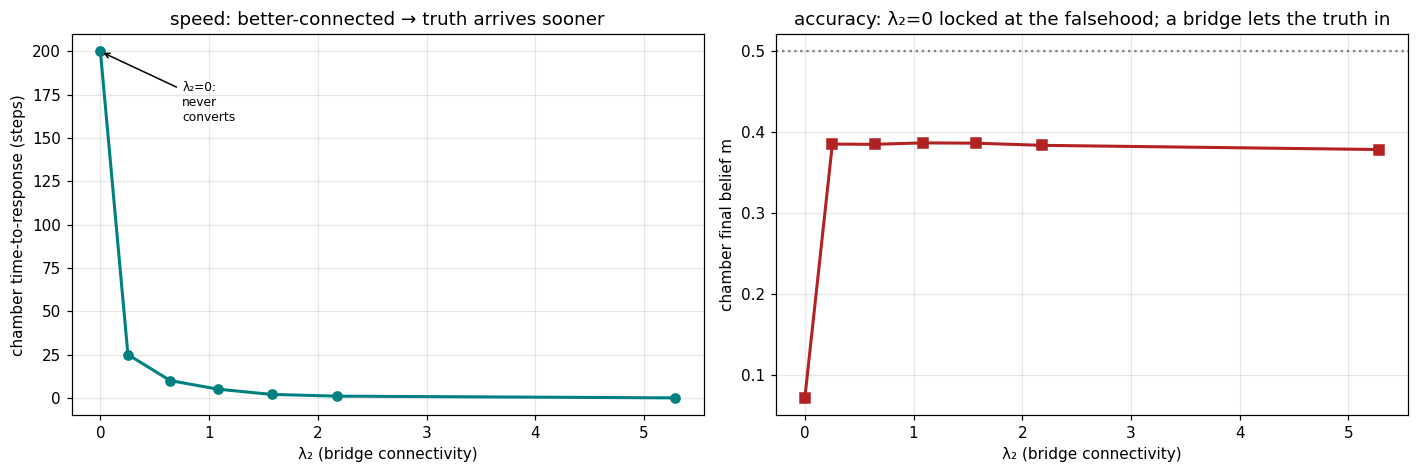

  inter=0.000  λ₂= 0.000  chamber_final=0.07  time-to-response=200 (never)
  inter=0.003  λ₂= 0.253  chamber_final=0.39  time-to-response=25
  inter=0.008  λ₂= 0.641  chamber_final=0.39  time-to-response=10
  inter=0.020  λ₂= 1.084  chamber_final=0.39  time-to-response=5
  inter=0.050  λ₂= 1.575  chamber_final=0.39  time-to-response=2
  inter=0.100  λ₂= 2.178  chamber_final=0.38  time-to-response=1
  inter=0.250  λ₂= 5.284  chamber_final=0.38  time-to-response=0
=> λ₂=0: permanent echo chamber (sensory gated + no social channel). λ₂>0: the bridge
   transmits the vanguard's belief, faster as λ₂ rises (partial — the gated channel drags back).


In [3]:
def chamber_run(inter, gov=400.0, n_steps=200, n_seeds=3):
    g = G.community([30, 30], intra=0.25, inter=inter, seed=1)
    cfg = dataclasses.replace(StructuralConfig(), n_agents=60, n_steps=n_steps, t_shift=0,
        observation_operator='relational', precision_mode='derived', core_governance=gov)
    groups = [{"count": 30, "paradigm": "oxygen", "stance": cfg.mu_oxy_mass},       # bubble
              {"count": 30, "paradigm": "phlogiston", "stance": cfg.mu_phlog_mass}] # gated chamber
    Wov = g.trust_W()
    fin, tt = [], []
    for s in range(n_seeds):
        st = S.init_state(cfg, jax.random.PRNGKey(s), groups=groups, W_override=Wov)
        b1 = np.asarray(S.run_trace_index(cfg, st))[:, 30:].mean(axis=1)   # chamber block
        fin.append(float(b1[-1])); tt.append(obs.time_to_half(b1))
    return G.algebraic_connectivity(g), np.mean(fin), np.mean(tt)

inters = [0.0, 0.003, 0.008, 0.02, 0.05, 0.1, 0.25]
res = [chamber_run(it) for it in inters]
l2 = np.array([r[0] for r in res]); fin = np.array([r[1] for r in res]); tt = np.array([r[2] for r in res])

fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.4))
a0.plot(l2, tt, 'o-', lw=2, color='teal')
a0.set_xlabel('λ₂ (bridge connectivity)'); a0.set_ylabel('chamber time-to-response (steps)')
a0.set_title('speed: better-connected → truth arrives sooner')
a0.annotate('λ₂=0:\nnever\nconverts', xy=(l2[0], tt[0]), xytext=(l2[1]+0.5, tt[0]-40),
            fontsize=8, arrowprops=dict(arrowstyle='->'))
a1.plot(l2, fin, 's-', lw=2, color='firebrick')
a1.axhline(0.5, color='grey', ls=':')
a1.set_xlabel('λ₂ (bridge connectivity)'); a1.set_ylabel('chamber final belief m')
a1.set_title('accuracy: λ₂=0 locked at the falsehood; a bridge lets the truth in')
plt.tight_layout(); plt.savefig('figures_nb34_chamber.png'); plt.show()
for it, r in zip(inters, res):
    tag = ' (never)' if r[2] >= 200 else ''
    print(f"  inter={it:5.3f}  λ₂={r[0]:6.3f}  chamber_final={r[1]:.2f}  time-to-response={r[2]:.0f}{tag}")
print("=> λ₂=0: permanent echo chamber (sensory gated + no social channel). λ₂>0: the bridge")
print("   transmits the vanguard's belief, faster as λ₂ rises (partial — the gated channel drags back).")

## §3 — Why a homogeneous population shows nothing (the honest scope)

Connectivity bites only when information is **unevenly held**. If every agent samples the same
world, fusion merely denoises a shared signal and the population-mean trajectory barely moves
with $\lambda_2$. We confirm the null so the §2 result is read correctly: $\lambda_2$ matters
because the chamber's information is *different* (gated), not because connectivity is a
universal accelerant.

In [4]:
def homog_tt(p, n_steps=160, n_seeds=3):
    g = G.watts_strogatz(N, mean_degree=4, rewiring_p=p, seed=1)
    cfg = dataclasses.replace(StructuralConfig(), n_agents=N, n_steps=n_steps, t_shift=40,
        observation_operator='relational', precision_mode='derived', core_governance=0.0)
    Wov = g.trust_W()
    tt = [obs.time_to_half(np.asarray(S.run_trace(cfg, S.init_state(cfg, jax.random.PRNGKey(s), W_override=Wov))[0]))
          for s in range(n_seeds)]
    return G.algebraic_connectivity(g), np.mean(tt)

print('homogeneous population (everyone sees the same world): time-to-half vs λ₂')
for p in (0.0, 0.1, 1.0):
    l2, tt_ = homog_tt(p)
    print(f'  p={p:.1f}  λ₂={l2:.3f}  time-to-half={tt_:.0f}  (flat: connectivity irrelevant)')

homogeneous population (everyone sees the same world): time-to-half vs λ₂


  p=0.0  λ₂=0.055  time-to-half=80  (flat: connectivity irrelevant)


  p=0.1  λ₂=0.156  time-to-half=80  (flat: connectivity irrelevant)


  p=1.0  λ₂=0.660  time-to-half=80  (flat: connectivity irrelevant)


## Verdict

`graphs.algebraic_connectivity` gives the Fiedler $\lambda_2$, and Watts–Strogatz rewiring
provides a degree-controlled connectivity knob (§1). Connectivity governs the dynamics exactly
in the regime the paper cares about — **unevenly held information** (§2): a γ-gated echo
chamber whose sensory correction is silenced converts *only* through the social bridge, so

* $\lambda_2 = 0$ — the truth never arrives: a permanent echo chamber (present-but-silenced
  sensory channel **and** no social channel);
* $\lambda_2 > 0$ — the bridge transmits the informed bubble's belief, and the time-to-response
  falls monotonically as $\lambda_2$ rises (the Zollman speed),

while a homogeneous population is insensitive to $\lambda_2$ (§3) — connectivity is not a
universal accelerant but the lever on *whose information reaches whom*. This is the
bubble-vs-echo-chamber distinction made mechanical, and the curator's hand on $\pi_s$ (the
social channel) as the third lever the paper names.